# Telemetry Analysis

**Phase 3 — Analytics | F1 Data Platform**

Lap-level and sample-level telemetry analysis using `staging.stg_fastf1_telemetry`.
All heavy aggregation is done query-side in DuckDB before pulling into pandas.

**Key questions:**
1. Where on track is time being gained or lost between two drivers?
2. How do throttle application and braking points differ?
3. Where is each driver using DRS?
4. How does gap to the car ahead evolve through a lap?
5. What does each driver's speed profile look like around the circuit?

**Renderers:**
- Track maps → **Matplotlib** (`LineCollection` — performant for continuous colour along a path)
- Traces, comparisons, gap charts → **Plotly** (interactive)

**Data source:** `staging.stg_fastf1_telemetry` — ~690K rows per round, 3–4 Hz sampling.

## 0. Setup

In [21]:
import sys
from pathlib import Path

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))

import duckdb
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize, BoundaryNorm, ListedColormap
from dotenv import load_dotenv

load_dotenv(repo_root / ".env")

# Parameters 
SEASON        = 2026
ROUND         = 3      
DRIVER_A      = "ALO"   
DRIVER_B      = "ANT"   
COMPARE_LAP   = None    
                        

PLOTLY_TEMPLATE = "plotly_dark"
MPL_STYLE       = "dark_background"

DB_PATH = repo_root / "dbt" / "data" / "f1_local.duckdb"
print(f"Season: {SEASON}  Round: {ROUND}  Drivers: {DRIVER_A} vs {DRIVER_B}")

Season: 2026  Round: 3  Drivers: ALO vs ANT


In [22]:
# DuckDB connection 
con = duckdb.connect(str(DB_PATH), read_only=True)

drivers_available = con.execute(f"""
    SELECT DISTINCT abbreviation, team,
           COUNT(*) AS rows
    FROM staging.stg_fastf1_telemetry
    WHERE season = {SEASON}
      AND round  = {ROUND}
    GROUP BY abbreviation, team
    ORDER BY abbreviation
""").df()

print(f"Drivers in Round {ROUND}:")
print(drivers_available.to_string(index=False))

available = drivers_available["abbreviation"].tolist()
for d in [DRIVER_A, DRIVER_B]:
    if d not in available:
        print(f"WARNING: {d} not found — check abbreviation spelling above")

Drivers in Round 3:
abbreviation            team  rows
         ALB        williams 39731
         ALO    aston_martin 39905
         ANT        mercedes 39700
         BEA    haas_f1_team 15514
         BOR            audi 40165
         BOT        cadillac 40028
         COL          alpine 40213
         GAS          alpine 39953
         HAD red_bull_racing 40141
         HAM         ferrari 39894
         HUL            audi 40109
         LAW    racing_bulls 40091
         LEC         ferrari 39817
         LIN    racing_bulls 40171
         NOR         mclaren 39883
         OCO    haas_f1_team 40101
         PER        cadillac 40411
         PIA         mclaren 39803
         RUS        mercedes 39820
         SAI        williams 40207
         STR    aston_martin 23834
         VER red_bull_racing 39956


In [23]:
# Use the lap with the minimum lap_time_seconds in the telemetry itself.
def get_best_lap(driver: str) -> int:
    result = con.execute(f"""
        SELECT lap_number, MIN(lap_time_seconds) AS lap_time
        FROM staging.stg_fastf1_telemetry
        WHERE season      = {SEASON}
          AND round       = {ROUND}
          AND abbreviation = '{driver}'
          AND lap_time_seconds > 0
        GROUP BY lap_number
        ORDER BY lap_time ASC
        LIMIT 1
    """).df()
    return int(result["lap_number"].iloc[0])

LAP_A = get_best_lap(DRIVER_A)
LAP_B = get_best_lap(DRIVER_B)
print(f"{DRIVER_A} comparison lap: {LAP_A}")
print(f"{DRIVER_B} comparison lap: {LAP_B}")

ALO comparison lap: 28
ANT comparison lap: 44


## 1. Load Telemetry for Comparison Laps

In [24]:
# Load single-lap telemetry for each driver 
def load_lap_telemetry(driver: str, lap: int) -> pd.DataFrame:
    return con.execute(f"""
        SELECT
            abbreviation,
            team,
            lap_number,
            distance,
            speed,
            throttle,
            brake,
            drs,
            rpm,
            n_gear,
            x, y, z,
            driver_ahead,
            distance_to_driver_ahead,
            track_status
        FROM staging.stg_fastf1_telemetry
        WHERE season      = {SEASON}
          AND round       = {ROUND}
          AND abbreviation = '{driver}'
          AND lap_number  = {lap}
        ORDER BY distance
    """).df()

tel_a = load_lap_telemetry(DRIVER_A, LAP_A)
tel_b = load_lap_telemetry(DRIVER_B, LAP_B)

print(f"{DRIVER_A} lap {LAP_A}: {len(tel_a)} samples")
print(f"{DRIVER_B} lap {LAP_B}: {len(tel_b)} samples")

ALO lap 28: 741 samples
ANT lap 44: 699 samples


In [25]:
# ── Interpolate both drivers onto a shared distance grid ──────────────────────
# Fixes sample count mismatch between drivers (e.g. 736 vs 719 points).
# Both drivers are resampled to N_GRID evenly-spaced distance points spanning
# the overlap of their laps. All comparison plots use the interpolated versions.

N_GRID = 700  

def interpolate_to_grid(tel: pd.DataFrame, dist_grid: np.ndarray) -> pd.DataFrame:
    """
    Resample a single-lap telemetry DataFrame onto a fixed distance grid.
    Only continuous numeric channels are interpolated.
    Non-numeric and identifier columns are broadcast as constants.
    """
    numeric_channels = ["speed", "throttle", "rpm", "n_gear",
                        "distance_to_driver_ahead"]
    boolean_channels = ["brake"]

    result = {"distance": dist_grid}

    for ch in numeric_channels:
        if ch in tel.columns:
            result[ch] = np.interp(dist_grid, tel["distance"], tel[ch].astype(float))

    for ch in boolean_channels:
        if ch in tel.columns:
            # Interpolate as float then round back to bool
            interp = np.interp(dist_grid, tel["distance"], tel[ch].astype(float))
            result[ch] = interp >= 0.5

    # DRS: nearest-neighbour (it's a discrete state — don't interpolate between values)
    if "drs" in tel.columns:
        indices = np.searchsorted(tel["distance"].values, dist_grid, side="left")
        indices = np.clip(indices, 0, len(tel) - 1)
        result["drs"] = tel["drs"].values[indices]

    # x/y/z: interpolate for the delta track map
    for ch in ["x", "y", "z"]:
        if ch in tel.columns:
            result[ch] = np.interp(dist_grid, tel["distance"], tel[ch])

    # Broadcast scalar identifiers
    result["abbreviation"] = tel["abbreviation"].iloc[0]
    result["team"]         = tel["team"].iloc[0]
    result["lap_number"]   = tel["lap_number"].iloc[0]

    return pd.DataFrame(result)


# Shared grid spans only the overlap between both laps
dist_min = max(tel_a["distance"].min(), tel_b["distance"].min())
dist_max = min(tel_a["distance"].max(), tel_b["distance"].max())
dist_grid = np.linspace(dist_min, dist_max, N_GRID)

tel_a_interp = interpolate_to_grid(tel_a, dist_grid)
tel_b_interp = interpolate_to_grid(tel_b, dist_grid)

print(f"Shared grid: {dist_min:.0f}m – {dist_max:.0f}m  ({N_GRID} points)")
print(f"Raw points — {DRIVER_A}: {len(tel_a)}, {DRIVER_B}: {len(tel_b)}")
print(f"Interpolated — both: {N_GRID} points  ✓")

Shared grid: 0m – 5757m  (700 points)
Raw points — ALO: 741, ANT: 699
Interpolated — both: 700 points  ✓


## 2. Track Maps — Matplotlib LineCollection

Each track map renders the circuit outline coloured by a telemetry channel.
Using `LineCollection` means a single artist handles all colour segments
efficiently — no per-point scatter overhead.

In [26]:
# ── Helper: build LineCollection from x/y + a scalar channel ─────────────────
def make_line_collection(x, y, values, cmap, norm, linewidth=3):
    """Convert x/y coordinates and a scalar channel into a LineCollection."""
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap, norm=norm, linewidth=linewidth,
                        capstyle="round")
    lc.set_array(values[:-1])
    return lc


def plot_track_map(df, channel, title, cmap_name, unit="", figsize=(12, 8)):
    """
    Render a single driver's track map coloured by `channel`.
    df must have columns: x, y, and the channel column.
    """
    with plt.style.context(MPLSTYLE if 'MPLSTYLE' in dir() else 'dark_background'):
        fig, ax = plt.subplots(figsize=figsize)
        fig.patch.set_facecolor("#1a1a2e")
        ax.set_facecolor("#1a1a2e")

        values = df[channel].values.astype(float)
        norm   = Normalize(vmin=np.nanpercentile(values, 2),
                           vmax=np.nanpercentile(values, 98))
        cmap   = cm.get_cmap(cmap_name)

        lc = make_line_collection(df["x"].values, df["y"].values,
                                  values, cmap, norm)
        ax.add_collection(lc)

        # Colorbar
        cb = fig.colorbar(lc, ax=ax, pad=0.02)
        cb.set_label(f"{channel} {unit}", color="white")
        cb.ax.yaxis.set_tick_params(color="white")
        plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")

        ax.autoscale_view()
        ax.set_aspect("equal")
        ax.axis("off")
        ax.set_title(title, color="white", fontsize=13, pad=12)

        plt.tight_layout()
        plt.show()

print("Track map helper defined.")

Track map helper defined.


/var/folders/64/x8zk6wgd48j2ww548p3vsmgc0000gn/T/ipykernel_20357/4145714167.py:25: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



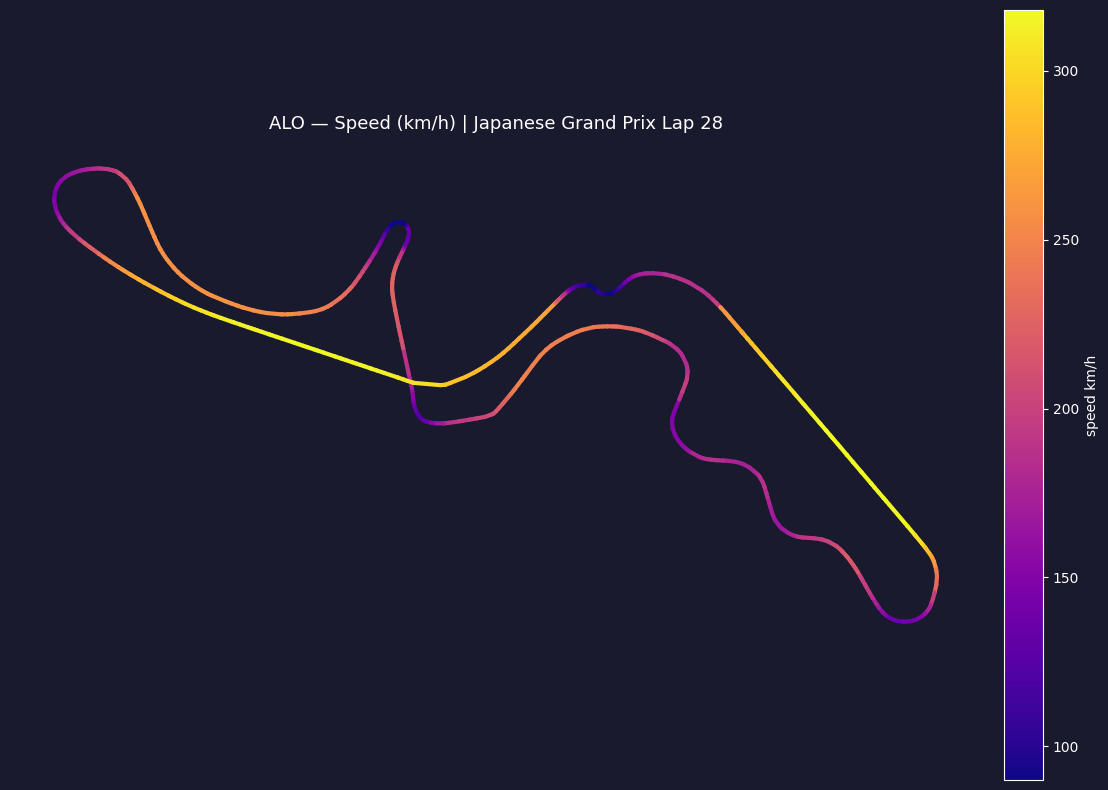

In [27]:
# ── 2.1 Speed map — Driver A ──────────────────────────────────────────────────
round_name = con.execute(f"""
    SELECT race_name FROM gold.mart_race_results
    WHERE season = {SEASON} AND round = {ROUND} LIMIT 1
""").df()["race_name"].iloc[0]

plot_track_map(
    tel_a, channel="speed",
    title=f"{DRIVER_A} — Speed (km/h) | {round_name} Lap {LAP_A}",
    cmap_name="plasma", unit="km/h",
)

/var/folders/64/x8zk6wgd48j2ww548p3vsmgc0000gn/T/ipykernel_20357/4145714167.py:25: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



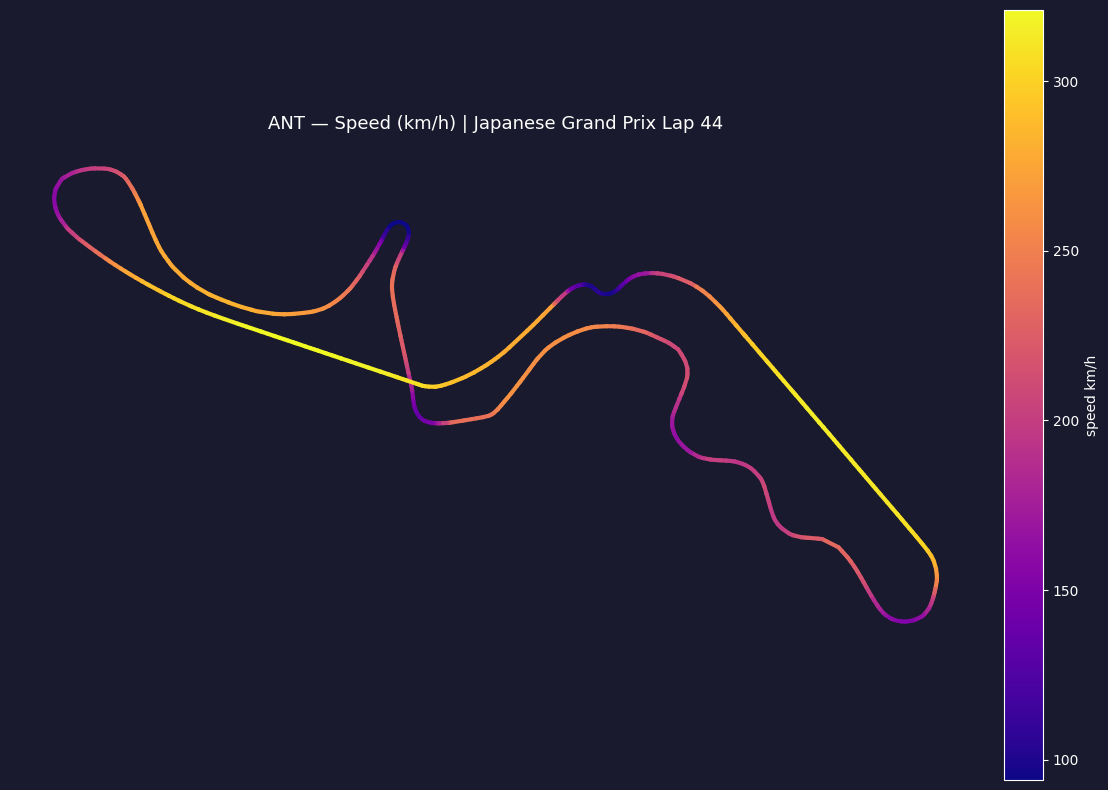

In [28]:
# ── 2.2 Speed map — Driver B ──────────────────────────────────────────────────
plot_track_map(
    tel_b, channel="speed",
    title=f"{DRIVER_B} — Speed (km/h) | {round_name} Lap {LAP_B}",
    cmap_name="plasma", unit="km/h",
)

/var/folders/64/x8zk6wgd48j2ww548p3vsmgc0000gn/T/ipykernel_20357/4145714167.py:25: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



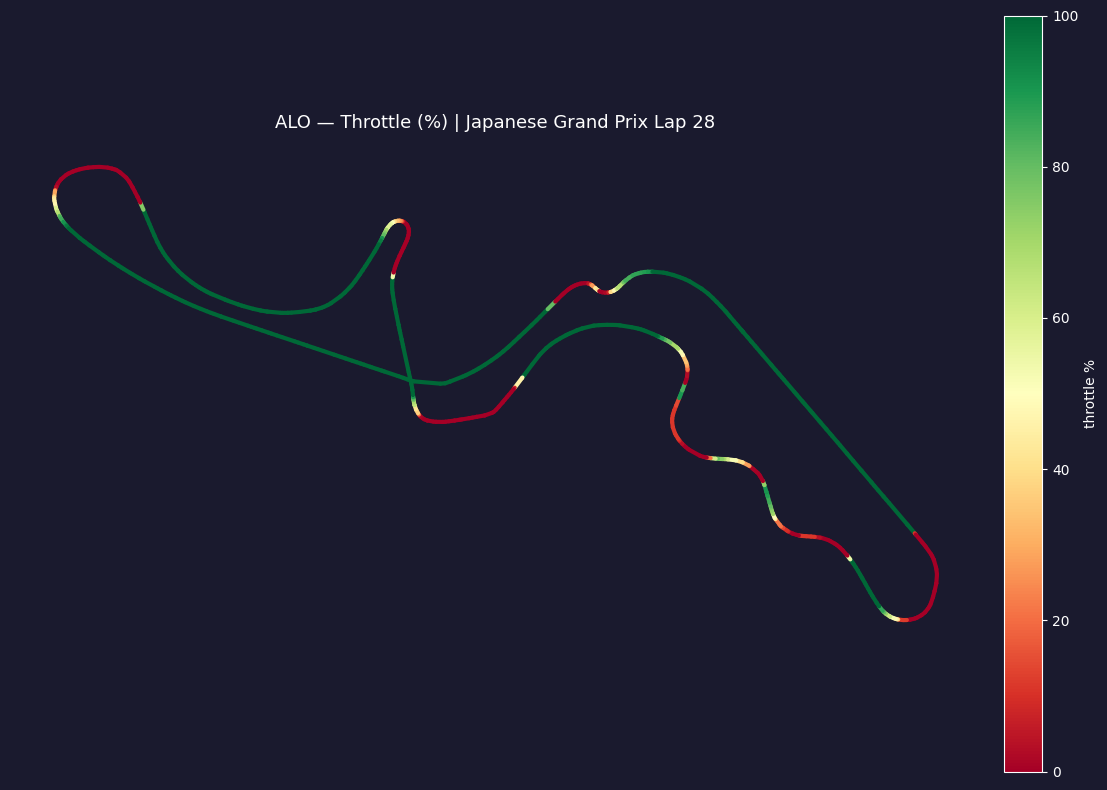

In [29]:
# ── 2.3 Throttle map — Driver A ───────────────────────────────────────────────
# Green = full throttle, dark = lift/coast
plot_track_map(
    tel_a, channel="throttle",
    title=f"{DRIVER_A} — Throttle (%) | {round_name} Lap {LAP_A}",
    cmap_name="RdYlGn", unit="%",
)

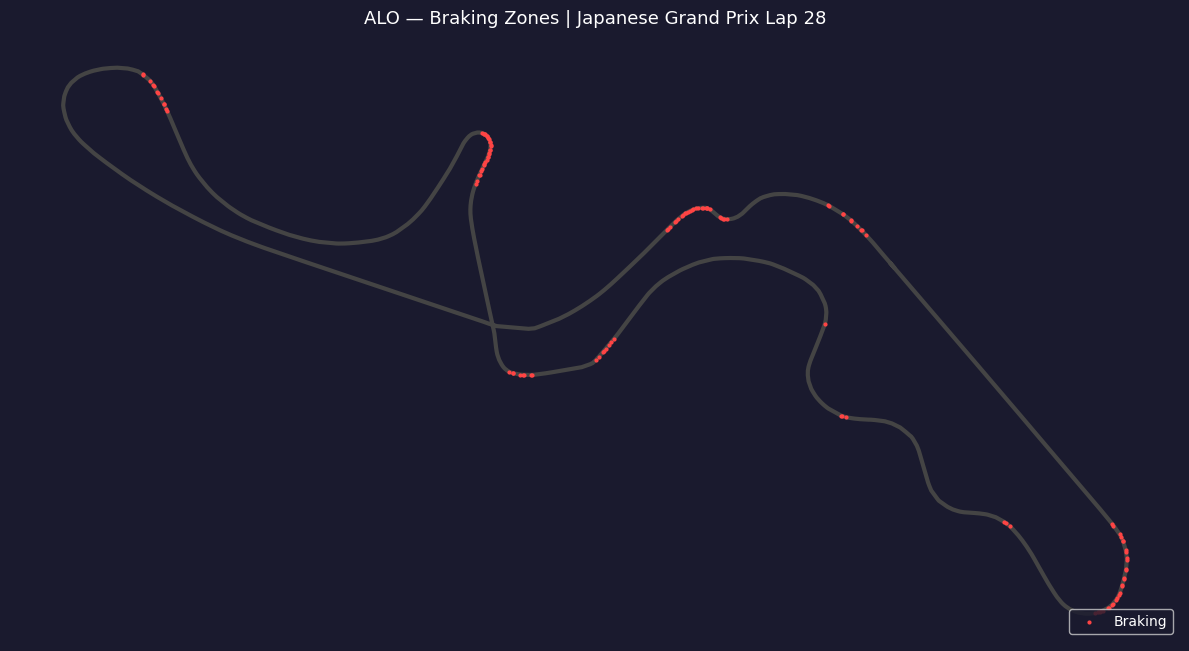

In [30]:
# ── 2.4 Brake map — Driver A ──────────────────────────────────────────────────
# Boolean brake flag — show braking zones in red
with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor("#1a1a2e")
    ax.set_facecolor("#1a1a2e")

    # Base track in grey
    ax.plot(tel_a["x"], tel_a["y"], color="#444444", linewidth=3, zorder=1)

    # Braking zones in red
    braking = tel_a[tel_a["brake"] == True]
    ax.scatter(braking["x"], braking["y"],
               color="#FF4444", s=4, zorder=2, label="Braking")

    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"{DRIVER_A} — Braking Zones | {round_name} Lap {LAP_A}",
                 color="white", fontsize=13, pad=12)
    ax.legend(facecolor="#1a1a2e", labelcolor="white", loc="lower right")
    plt.tight_layout()
    plt.show()

/var/folders/64/x8zk6wgd48j2ww548p3vsmgc0000gn/T/ipykernel_20357/4197819632.py:16: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



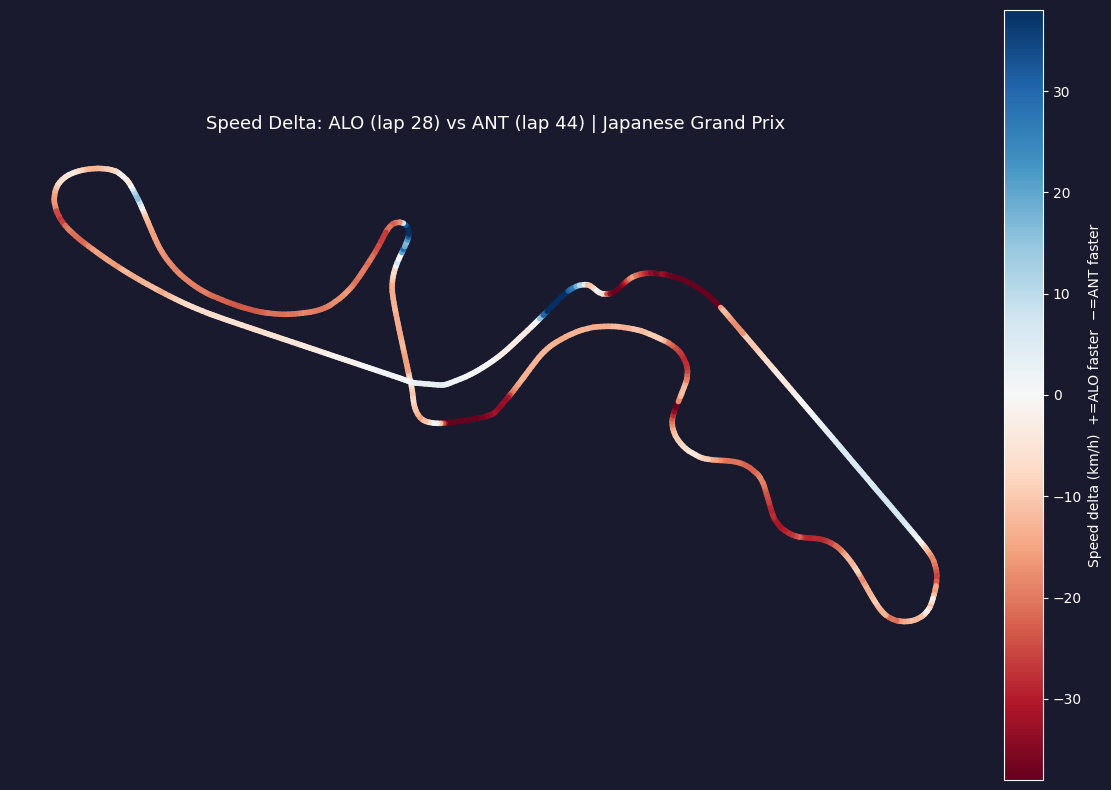

In [31]:
# ── 2.5 Speed delta map — A vs B ─────────────────────────────────────────────
# Interpolate both drivers onto a common distance grid, then colour the track
# by who is faster at each point. Blue = Driver A faster, Red = Driver B faster.

speed_delta = tel_a_interp["speed"].values - tel_b_interp["speed"].values
x_grid      = tel_a_interp["x"].values
y_grid      = tel_a_interp["y"].values

# Interpolate x/y from Driver A for the track outline
x_grid = np.interp(dist_grid, tel_a["distance"], tel_a["x"])
y_grid = np.interp(dist_grid, tel_a["distance"], tel_a["y"])

# Diverging colormap centred at 0
abs_max = np.percentile(np.abs(speed_delta), 95)
norm_div = Normalize(vmin=-abs_max, vmax=abs_max)
cmap_div = cm.get_cmap("RdBu")  # Blue = A faster, Red = B faster

with plt.style.context("dark_background"):
    fig, ax = plt.subplots(figsize=(12, 8))
    fig.patch.set_facecolor("#1a1a2e")
    ax.set_facecolor("#1a1a2e")

    points   = np.array([x_grid, y_grid]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, cmap=cmap_div, norm=norm_div,
                        linewidth=4, capstyle="round")
    lc.set_array(speed_delta[:-1])
    ax.add_collection(lc)

    cb = fig.colorbar(lc, ax=ax, pad=0.02)
    cb.set_label(f"Speed delta (km/h)  +={DRIVER_A} faster  −={DRIVER_B} faster",
                 color="white")
    cb.ax.yaxis.set_tick_params(color="white")
    plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")

    ax.autoscale_view()
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(
        f"Speed Delta: {DRIVER_A} (lap {LAP_A}) vs {DRIVER_B} (lap {LAP_B}) | {round_name}",
        color="white", fontsize=13, pad=12,
    )
    plt.tight_layout()
    plt.show()

## 3. Speed & Throttle Traces — Plotly

In [32]:
# ── 3.1 Speed trace overlay ───────────────────────────────────────────────────
# Overlay both drivers on the same distance axis.
# Gaps in the line at distance discontinuities are expected (pit entry/exit).
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=tel_a_interp["distance"], y=tel_a_interp["speed"],
    name=f"{DRIVER_A} (lap {LAP_A})",
    mode="lines", line=dict(width=1.5),
))
fig.add_trace(go.Scatter(
    x=tel_b_interp["distance"], y=tel_b_interp["speed"],
    name=f"{DRIVER_B} (lap {LAP_B})",
    mode="lines", line=dict(width=1.5),
))

fig.update_layout(
    title=f"Speed Trace — {DRIVER_A} vs {DRIVER_B} | {round_name}",
    xaxis_title="Distance (m)",
    yaxis_title="Speed (km/h)",
    template=PLOTLY_TEMPLATE,
    height=400,
    hovermode="x unified",
)
fig.show()

In [33]:
# ── 3.2 Speed delta trace ─────────────────────────────────────────────────────
# Positive = Driver A faster at that point on track.
# Use the interpolated grid computed in section 2.5.
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=dist_grid, y=speed_delta,
    mode="lines",
    name=f"{DRIVER_A} − {DRIVER_B}",
    line=dict(width=1.5),
    fill="tozeroy",
))
fig.add_hline(y=0, line_dash="dash", line_color="white", opacity=0.4)

fig.update_layout(
    title=(
        f"Speed Delta: {DRIVER_A} (lap {LAP_A}) − {DRIVER_B} (lap {LAP_B}) | {round_name}<br>"
        f"<sup>Positive = {DRIVER_A} faster | Negative = {DRIVER_B} faster</sup>"
    ),
    xaxis_title="Distance (m)",
    yaxis_title="Speed delta (km/h)",
    template=PLOTLY_TEMPLATE,
    height=350,
    hovermode="x unified",
)
fig.show()

In [34]:
# ── 3.x Cumulative lap time & delta — distance on X axis ─────────────────────
# Cumulative time is computed by integrating over the shared distance grid.
# At each point: time = distance / speed  (speed in km/h → convert to m/s)
# This gives seconds elapsed from the start of the lap to each distance point.
#
# The delta subplot shows (time_a - time_b) at each point:
#   positive = Driver A is behind on time (B is ahead)
#   negative = Driver A is ahead on time (A is ahead)

def cumulative_time(tel_interp: pd.DataFrame) -> np.ndarray:
    """
    Compute cumulative elapsed time (seconds) at each distance grid point.
    Uses the trapezoid rule: dt = dd / v  where v is speed in m/s.
    """
    speed_ms = tel_interp["speed"].values / 3.6  # km/h → m/s
    speed_ms = np.where(speed_ms < 1.0, 1.0, speed_ms)  # guard against div/0 at standing start
    dist     = tel_interp["distance"].values
    dd       = np.diff(dist, prepend=dist[0])  # distance increment per step
    dt       = dd / speed_ms                   # time increment per step
    return np.cumsum(dt)

cum_time_a = cumulative_time(tel_a_interp)
cum_time_b = cumulative_time(tel_b_interp)
time_delta = cum_time_a - cum_time_b  # + = A losing time, - = A gaining time

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    row_heights=[0.6, 0.4],
    subplot_titles=[
        f"Cumulative Lap Time — {DRIVER_A} (lap {LAP_A}) vs {DRIVER_B} (lap {LAP_B})",
        f"Time Delta: {DRIVER_A} − {DRIVER_B}  (+ = {DRIVER_A} losing time)",
    ],
)

# ── Top panel: cumulative time both drivers ───────────────────────────────────
fig.add_trace(go.Scatter(
    x=dist_grid, y=cum_time_a,
    name=f"{DRIVER_A} (lap {LAP_A})",
    mode="lines", line=dict(width=2),
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=dist_grid, y=cum_time_b,
    name=f"{DRIVER_B} (lap {LAP_B})",
    mode="lines", line=dict(width=2),
), row=1, col=1)

# ── Bottom panel: time delta with zero line and fill ─────────────────────────
fig.add_trace(go.Scatter(
    x=dist_grid, y=time_delta,
    name=f"Δ {DRIVER_A}−{DRIVER_B}",
    mode="lines", line=dict(width=1.5),
    fill="tozeroy",
    showlegend=True,
), row=2, col=1)

fig.add_hline(
    y=0, line_dash="dash", line_color="white",
    opacity=0.4, row=2, col=1,
)

fig.update_layout(
    template=PLOTLY_TEMPLATE,
    height=600,
    hovermode="x unified",
    title=f"Lap Time vs Distance — {round_name} | {DRIVER_A} vs {DRIVER_B}",
)
fig.update_xaxes(title_text="Distance (m)", row=2, col=1)
fig.update_yaxes(title_text="Elapsed time (s)", row=1, col=1)
fig.update_yaxes(title_text="Delta (s)", row=2, col=1)

fig.show()

In [35]:
# ── 3.3 Throttle & brake traces — 4-panel subplot ────────────────────────────
# Speed / Throttle / Brake / Gear stacked on a shared distance axis.
# Shows the full driving style picture in one view.
fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.04,
    subplot_titles=["Speed (km/h)", "Throttle (%)", "Brake", "Gear"],
)

channels = [
    ("speed",    1),
    ("throttle", 2),
    ("brake",    3),
    ("n_gear",   4),
]

for channel, row in channels:
    for driver, tel, lap in [(DRIVER_A, tel_a_interp, LAP_A), (DRIVER_B, tel_b_interp, LAP_B)]:
        fig.add_trace(
            go.Scatter(
                x=tel["distance"],
                y=tel[channel].astype(float),
                name=f"{driver} (lap {lap})",
                mode="lines",
                line=dict(width=1.2),
                showlegend=(row == 1),  # legend only on first panel
            ),
            row=row, col=1,
        )

fig.update_layout(
    title=f"Driver Comparison — {DRIVER_A} vs {DRIVER_B} | {round_name}",
    template=PLOTLY_TEMPLATE,
    height=800,
    hovermode="x unified",
)
fig.update_xaxes(title_text="Distance (m)", row=4, col=1)
fig.show()

## 4. Gap to Driver Ahead

In [36]:
# ── 5.1 Gap trace through the comparison lap ──────────────────────────────────
# Shows how the gap to the car ahead evolves through a single lap.
# Useful for identifying attack/defend phases and DRS train dynamics.
# Filter out distance=0 rows (standing start / outlap artefacts)
# and cap at 3s for readability (beyond 3s DRS is irrelevant).

fig = go.Figure()

for driver, tel, lap in [(DRIVER_A, tel_a, LAP_A), (DRIVER_B, tel_b, LAP_B)]:
    gap_data = tel[
        (tel["distance_to_driver_ahead"] > 0) &
        (tel["distance_to_driver_ahead"].notna())
    ].copy()

    fig.add_trace(go.Scatter(
        x=gap_data["distance"],
        y=gap_data["distance_to_driver_ahead"],
        name=f"{driver} (lap {lap})",
        mode="lines",
        line=dict(width=1.5),
    ))

# DRS detection threshold line
fig.add_hline(
    y=1.0, line_dash="dash", line_color="#00FF88",
    annotation_text="DRS detection (1s)",
    annotation_position="top right",
    opacity=0.6,
)

fig.update_layout(
    title=f"Gap to Driver Ahead — {DRIVER_A} vs {DRIVER_B} | {round_name}",
    xaxis_title="Distance (m)",
    yaxis_title="Gap to driver ahead (m)",
    yaxis_range=[0, 150],  # cap for readability — adjust if running in clean air
    template=PLOTLY_TEMPLATE,
    height=400,
    hovermode="x unified",
)
fig.show()

In [37]:
# ── 5.2 Laps spent within DRS range — full race ───────────────────────────────
# For each lap, what % of samples was the driver within 1s of the car ahead?
# High % = in a DRS train or pressuring for an overtake.
drs_range = con.execute(f"""
    SELECT
        abbreviation,
        lap_number,
        ROUND(
            100.0 * SUM(CASE
                WHEN distance_to_driver_ahead > 0
                 AND distance_to_driver_ahead <= 1.0 THEN 1
                ELSE 0
            END) / COUNT(*),
            1
        ) AS pct_within_drs_range
    FROM staging.stg_fastf1_telemetry
    WHERE season      = {SEASON}
      AND round       = {ROUND}
      AND abbreviation IN ('{DRIVER_A}', '{DRIVER_B}')
    GROUP BY abbreviation, lap_number
    ORDER BY abbreviation, lap_number
""").df()

fig = px.bar(
    drs_range,
    x="lap_number",
    y="pct_within_drs_range",
    color="abbreviation",
    barmode="group",
    title=f"% of Lap Within DRS Range (≤1s) — {DRIVER_A} vs {DRIVER_B} | {round_name}",
    labels={
        "lap_number": "Lap",
        "pct_within_drs_range": "% samples within 1s",
        "abbreviation": "Driver",
    },
    template=PLOTLY_TEMPLATE,
)
fig.update_layout(height=400)
fig.show()

## 6. Sector-Level Speed Analysis

In [38]:
# ── 6.1 Speed distribution by gear — driving style fingerprint ───────────────
# Query-side aggregation — no need to load full telemetry
gear_speed = con.execute(f"""
    SELECT
        abbreviation,
        n_gear,
        ROUND(AVG(speed), 1)   AS avg_speed,
        ROUND(MAX(speed), 1)   AS max_speed,
        COUNT(*)               AS samples
    FROM staging.stg_fastf1_telemetry
    WHERE season      = {SEASON}
      AND round       = {ROUND}
      AND abbreviation IN ('{DRIVER_A}', '{DRIVER_B}')
      AND n_gear      > 0
      AND speed       > 0
    GROUP BY abbreviation, n_gear
    ORDER BY abbreviation, n_gear
""").df()

fig = px.bar(
    gear_speed,
    x="n_gear",
    y="avg_speed",
    color="abbreviation",
    barmode="group",
    title=f"Average Speed by Gear — {DRIVER_A} vs {DRIVER_B} | {round_name}",
    labels={
        "n_gear": "Gear",
        "avg_speed": "Avg speed (km/h)",
        "abbreviation": "Driver",
    },
    template=PLOTLY_TEMPLATE,
    text="avg_speed",
)
fig.update_traces(textposition="outside")
fig.update_layout(height=450)
fig.show()

In [39]:
# ── 6.2 Throttle application — full throttle vs partial vs lift ───────────────
# Breaks throttle into three bands: full (>98%), partial (20–98%), lift (<20%)
# High full-throttle % = aggressive, high-downforce track or powerful PU
throttle_bands = con.execute(f"""
    SELECT
        abbreviation,
        ROUND(
            100.0 * SUM(CASE WHEN throttle >= 98 THEN 1 ELSE 0 END) / COUNT(*), 1
        ) AS full_throttle_pct,
        ROUND(
            100.0 * SUM(CASE WHEN throttle >= 20 AND throttle < 98 THEN 1 ELSE 0 END) / COUNT(*), 1
        ) AS partial_throttle_pct,
        ROUND(
            100.0 * SUM(CASE WHEN throttle < 20 THEN 1 ELSE 0 END) / COUNT(*), 1
        ) AS lift_pct
    FROM staging.stg_fastf1_telemetry
    WHERE season      = {SEASON}
      AND round       = {ROUND}
      AND abbreviation IN ('{DRIVER_A}', '{DRIVER_B}')
    GROUP BY abbreviation
""").df()

throttle_melted = throttle_bands.melt(
    id_vars="abbreviation",
    value_vars=["full_throttle_pct", "partial_throttle_pct", "lift_pct"],
    var_name="band",
    value_name="pct",
)
throttle_melted["band"] = throttle_melted["band"].str.replace("_pct", "").str.replace("_", " ")

fig = px.bar(
    throttle_melted,
    x="abbreviation",
    y="pct",
    color="band",
    title=f"Throttle Application Breakdown — {DRIVER_A} vs {DRIVER_B} | {round_name}",
    labels={"abbreviation": "Driver", "pct": "%", "band": "Throttle band"},
    template=PLOTLY_TEMPLATE,
    text="pct",
    color_discrete_map={
        "full throttle": "#00CC66",
        "partial throttle": "#FFAA00",
        "lift": "#CC3333",
    },
)
fig.update_traces(textposition="inside")
fig.update_layout(height=420, barmode="stack")
fig.show()

In [40]:
# ── Close connection ──────────────────────────────────────────────────────────
con.close()
print("DuckDB connection closed.")

DuckDB connection closed.


---

## Notes

- Source: `staging.stg_fastf1_telemetry` — ~690K rows per round.
- All multi-lap aggregations are done query-side in DuckDB before loading into pandas.
- Single-lap loads (sections 2–3) pull ~2–3K rows per driver — safe to load in full.
- Track maps use Matplotlib `LineCollection` — far more performant than Plotly scatter
  for continuous colour along a path.
- `DRIVER_A`, `DRIVER_B`, `ROUND`, and `COMPARE_LAP` are all set in Section 0.
  Re-run from Section 1 downward after changing parameters.
- DRS encoding: values ≥ 8 = open (FastF1 uses 8/10/12/14 for open states).
- `distance_to_driver_ahead` is in seconds (FastF1 convention), not metres,
  despite the column name — verify against your Silver cleaning if values look off.

**Next:** `02_team_analysis.ipynb` — constructor pace, pit stop performance, operational excellence.